mean_final_equity: 603304.6594233842
median_final_equity: 544472.4888182599
worst_drawdown: -0.5330900382753854
median_drawdown: -0.16019295933361397
probability_of_loss: 5.3e-05


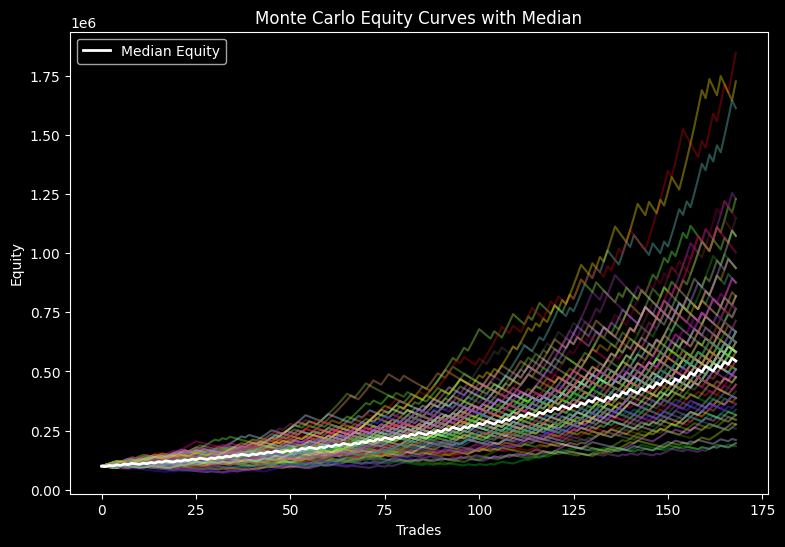

In [1]:
from simulation.monte_carlo import MonteCarlo

import matplotlib.pyplot as plt
import numpy as np


mc = MonteCarlo()
curves = mc.run_monte_carlo(
    n_runs=1000000,
    n_trades=14*12,
    winrate=0.447,
    reward=2.44,
    risk=0.02
)

metrics = mc.compute_metrics(curves)

for metric in metrics:
    print(f"{metric}: {metrics[metric]}")


# Sample a subset of curves to avoid clutter
n_plot = 100
sample_curves = curves[:n_plot]

# Use dark style
plt.style.use('dark_background')
plt.figure(figsize=(9,6))

# Plot the individual curves with random colors
for curve in sample_curves:
    plt.plot(curve, color=np.random.rand(3,), alpha=0.4)

# Median curve
median_curve = np.median(curves, axis=0)
plt.plot(median_curve, color='white', linewidth=2, label='Median Equity')

plt.xlabel("Trades", color='white')
plt.ylabel("Equity", color='white')
plt.title("Monte Carlo Equity Curves with Median", color='white')
plt.legend()
plt.show()